
=========== PORTAL MENU ===========
1 Dashboard
2 Student Leaderboard
3 Department Performance
4 CS Pipeline
5 Search Student
6 Department Chart
7 GPA Chart
8 Export Report
9 Exit



Select Option:  1



ACADEMIC PORTAL DASHBOARD
Total Students: 550
Average GPA: 3.02
Highest GPA: 4.0
Lowest GPA: 2.0

Top Departments by Students
department
Artificial Intelligence    111
Cyber Security              94
Software Engineering        91
Data Science                90
Information Technology      86
Computer Science            78
Name: count, dtype: int64

=========== PORTAL MENU ===========
1 Dashboard
2 Student Leaderboard
3 Department Performance
4 CS Pipeline
5 Search Student
6 Department Chart
7 GPA Chart
8 Export Report
9 Exit



Select Option:  2



TOP STUDENT LEADERBOARD
     Rank student_id            name               department   gpa
186     1      S0187       Taha Khan  Artificial Intelligence  4.00
221     2      S0222    Areeba Akram           Cyber Security  4.00
459     3      S0460     Hamza Ahmed             Data Science  3.99
285     4      S0286       Saad Butt   Information Technology  3.99
291     5      S0292    Talha Farooq     Software Engineering  3.98
53      6      S0054    Hussain Khan             Data Science  3.98
111     7      S0112     Bilal Malik         Computer Science  3.98
307     8      S0308      Zain Nawaz           Cyber Security  3.98
66      9      S0067  Ahmed Siddiqui             Data Science  3.97
398    10      S0399       Saad Butt     Software Engineering  3.96

=========== PORTAL MENU ===========
1 Dashboard
2 Student Leaderboard
3 Department Performance
4 CS Pipeline
5 Search Student
6 Department Chart
7 GPA Chart
8 Export Report
9 Exit


...


Select Option:  4



CS HIGH PERFORMERS
    student_id             name   gpa
111      S0112      Bilal Malik  3.98
494      S0495    Saad Siddiqui  3.95
392      S0393        Zain Khan  3.94
325      S0326       Saad Malik  3.94
158      S0159      Hassan Raza  3.93
500      S0501      Ayesha Raza  3.93
472      S0473       Dua Sheikh  3.92
97       S0098      Ahmed Nawaz  3.90
479      S0480  Maryam Siddiqui  3.89
119      S0120       Ali Sheikh  3.88

=========== PORTAL MENU ===========
1 Dashboard
2 Student Leaderboard
3 Department Performance
4 CS Pipeline
5 Search Student
6 Department Chart
7 GPA Chart
8 Export Report
9 Exit



Select Option:  5

Enter Student ID:  97


Student not found

=========== PORTAL MENU ===========
1 Dashboard
2 Student Leaderboard
3 Department Performance
4 CS Pipeline
5 Search Student
6 Department Chart
7 GPA Chart
8 Export Report
9 Exit



Select Option:  6


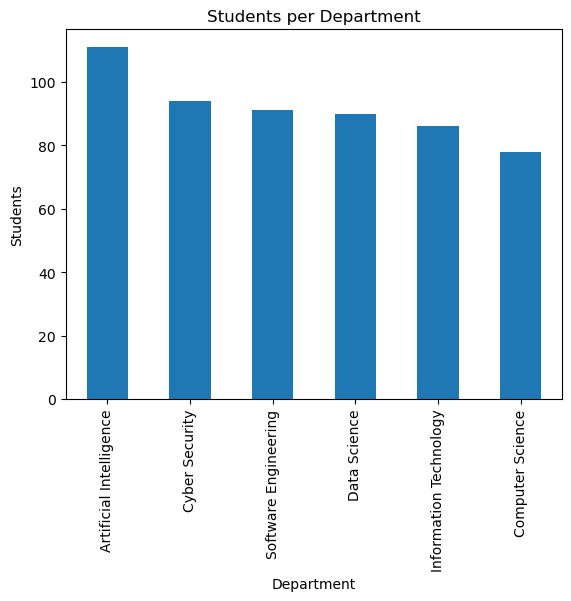


=========== PORTAL MENU ===========
1 Dashboard
2 Student Leaderboard
3 Department Performance
4 CS Pipeline
5 Search Student
6 Department Chart
7 GPA Chart
8 Export Report
9 Exit



Select Option:  8


Report Exported Successfully

=========== PORTAL MENU ===========
1 Dashboard
2 Student Leaderboard
3 Department Performance
4 CS Pipeline
5 Search Student
6 Department Chart
7 GPA Chart
8 Export Report
9 Exit



Select Option:  9


Portal Closed


In [3]:
# ==========================================
# Academic Portal Analytics System
# FINAL Project
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt
import logging


# -----------------------------
# Logging Setup
# -----------------------------

logging.basicConfig(
    filename="portal.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s"
)

logging.info("Portal Started")


# -----------------------------
# Load Student Data
# -----------------------------

def load_students(file):

    try:

        df = pd.read_csv(file)

        logging.info("CSV Loaded Successfully")

        return df

    except Exception as e:

        logging.error("Error loading file")

        print(e)


# -----------------------------
# Dashboard Analytics
# -----------------------------

def dashboard(df):

    print("\n==============================")
    print("ACADEMIC PORTAL DASHBOARD")
    print("==============================")

    print("Total Students:", len(df))
    print("Average GPA:", round(df["gpa"].mean(),2))
    print("Highest GPA:", df["gpa"].max())
    print("Lowest GPA:", df["gpa"].min())

    print("\nTop Departments by Students")

    dept = df["department"].value_counts()

    print(dept)


# -----------------------------
# Student Leaderboard
# -----------------------------

def leaderboard(df):

    print("\n==============================")
    print("TOP STUDENT LEADERBOARD")
    print("==============================")

    rank = df.sort_values(by="gpa",ascending=False)

    rank["Rank"] = range(1,len(rank)+1)

    print(rank[["Rank","student_id","name","department","gpa"]].head(10))


# -----------------------------
# Department Performance
# -----------------------------

def department_performance(df):

    print("\n==============================")
    print("DEPARTMENT PERFORMANCE")
    print("==============================")

    stats = df.groupby("department").agg({

        "student_id":"count",
        "gpa":"mean",
        "credits":"mean"

    })

    stats.columns=["Students","Average GPA","Average Credits"]

    print(stats)


# -----------------------------
# Functional Pipeline
# -----------------------------

def cs_pipeline(df):

    print("\n==============================")
    print("CS HIGH PERFORMERS")
    print("==============================")

    result = (
        df[df["department"]=="Computer Science"]
        .query("gpa > 3.0")
        .sort_values(by="gpa",ascending=False)
        .head(10)
    )

    print(result[["student_id","name","gpa"]])


# -----------------------------
# Student Search
# -----------------------------

def search_student(df):

    sid = input("\nEnter Student ID: ")

    student = df[df["student_id"]==sid]

    if student.empty:

        print("Student not found")

    else:

        print("\nStudent Record\n")

        print(student)


# -----------------------------
# Charts
# -----------------------------

def department_chart(df):

    dept = df["department"].value_counts()

    plt.figure()

    dept.plot(kind="bar")

    plt.title("Students per Department")

    plt.xlabel("Department")

    plt.ylabel("Students")

    plt.show()


def gpa_chart(df):

    gpa = df.groupby("department")["gpa"].mean()

    plt.figure()

    gpa.plot(kind="bar")

    plt.title("Average GPA by Department")

    plt.xlabel("Department")

    plt.ylabel("GPA")

    plt.show()


# -----------------------------
# Export Reports
# -----------------------------

def export_report(df):

    report = df.sort_values(by="gpa",ascending=False)

    report.to_csv("student_leaderboard.csv",index=False)

    print("Report Exported Successfully")


# -----------------------------
# Menu System
# -----------------------------

def portal_menu(df):

    while True:

        print("\n=========== PORTAL MENU ===========")

        print("1 Dashboard")

        print("2 Student Leaderboard")

        print("3 Department Performance")

        print("4 CS Pipeline")

        print("5 Search Student")

        print("6 Department Chart")

        print("7 GPA Chart")

        print("8 Export Report")

        print("9 Exit")

        choice = input("\nSelect Option: ")

        if choice == "1":

            dashboard(df)

        elif choice == "2":

            leaderboard(df)

        elif choice == "3":

            department_performance(df)

        elif choice == "4":

            cs_pipeline(df)

        elif choice == "5":

            search_student(df)

        elif choice == "6":

            department_chart(df)

        elif choice == "7":

            gpa_chart(df)

        elif choice == "8":

            export_report(df)

        elif choice == "9":

            print("Portal Closed")

            break

        else:

            print("Invalid option")


# -----------------------------
# Main Program
# -----------------------------

def main():

    file = "students_550_academic_portal.csv"

    students = load_students(file)

    portal_menu(students)

    logging.info("Portal Finished")


main()